In [1]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

In [2]:
from tensorflow.keras.datasets import mnist

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [4]:
# Data Pre-Processing

X_train = X_train.reshape(*X_train.shape, 1)
X_test = X_test.reshape(*X_test.shape, 1)

In [5]:
X_train.shape

(60000, 28, 28, 1)

In [6]:
X_test.shape

(10000, 28, 28, 1)

In [7]:
y_train.shape

(60000,)

In [8]:
#Min-Max Scaling

X_train = X_train / 255
X_test = X_test / 255

In [9]:
# Target Encoding with OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

y_train_enc = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_enc = encoder.transform(y_test.reshape(-1, 1))

print(y_train_enc.shape, y_test_enc.shape)

(60000, 10) (10000, 10)


In [10]:
# Build the CNN (LeNet-style architecture)
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(6, kernel_size=(5, 5), strides=1, activation='relu'),    # Conv 1 -> 24x24x6
    MaxPooling2D(pool_size=(2, 2), strides=2),                      # Pool 1 -> 12x12x6
    Conv2D(16, kernel_size=(5, 5), strides=1, activation='relu'),   # Conv 2 -> 8x8x16
    MaxPooling2D(pool_size=(2, 2), strides=2),                      # Pool 2 -> 4x4x16
    Flatten(),                                                      # 256 values
    Dense(120, activation='relu'),                                  # FC 1
    Dense(100, activation='relu'),                                  # FC 2
    Dense(10, activation='softmax')                                 # Output
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        12,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,522 (181.73 KB)

 Trainable params: 46,522 (181.73 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Train the model
history = model.fit(
    X_train, y_train_enc,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8935 - loss: 0.3585 - val_accuracy: 0.9705 - val_loss: 0.1001
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9708 - loss: 0.0951 - val_accuracy: 0.9807 - val_loss: 0.0681
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9791 - loss: 0.0670 - val_accuracy: 0.9833 - val_loss: 0.0569
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9830 - loss: 0.0543 - val_accuracy: 0.9850 - val_loss: 0.0532
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9862 - loss: 0.0447 - val_accuracy: 0.9862 - val_loss: 0.0453
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9881 - loss: 0.0380 - val_accuracy: 0.9882 - val_loss: 0.0388
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9899 - loss: 0.0318 - val_accuracy: 0.9878 - val_loss: 0.0432
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9905 - loss: 0.0287 - val_accuracy: 0.

In [13]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(X_test, y_test_enc)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9896 - loss: 0.0357
Test loss: 0.0357
Test accuracy: 0.9896


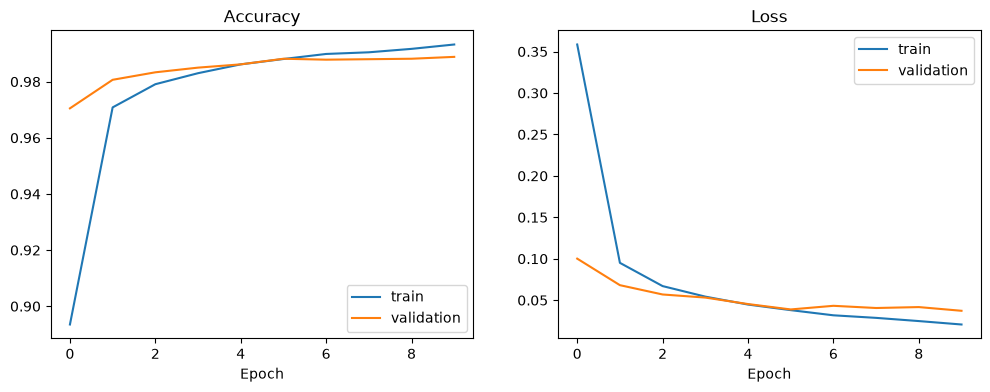

In [14]:
# Training curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['accuracy'], label='train')
ax[0].plot(history.history['val_accuracy'], label='validation')
ax[0].set_title('Accuracy'); ax[0].set_xlabel('Epoch'); ax[0].legend()
ax[1].plot(history.history['loss'], label='train')
ax[1].plot(history.history['val_loss'], label='validation')
ax[1].set_title('Loss'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


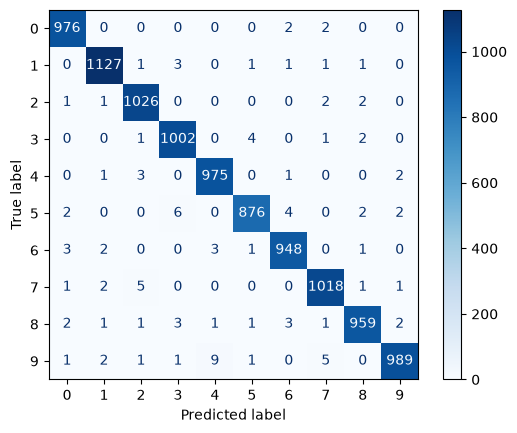

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [15]:
# Predictions, confusion matrix and classification report
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = np.argmax(model.predict(X_test), axis=1)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap='Blues')
plt.show()

print(classification_report(y_test, y_pred))

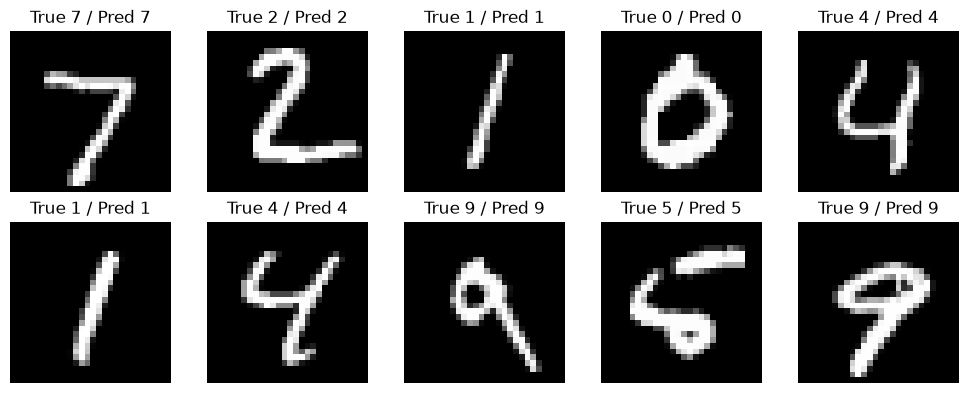

In [16]:
# Look at a few predictions
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True {y_test[i]} / Pred {y_pred[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()